# Assignment 06: Traffic Sign Classification using CNN

## Tata Technologies – TechPulse FY-26: Applied AI & ML

### Lab Statement 6
**Traffic Sign Classification using Convolutional Neural Networks**

### Domain
Advanced Driver Assistance Systems (ADAS)  
Autonomous Perception  
Camera-Based Traffic Sign Recognition (TSR)

### Dataset
German Traffic Sign Recognition Benchmark (GTSRB)

### Framework
PyTorch

### Objective
Train a Convolutional Neural Network (CNN) to classify traffic signs into
multiple categories using the GTSRB dataset.

### Key Concepts
- Image preprocessing
- CNN architecture
- Convolution and pooling
- Batch Normalization
- Dropout
- Cross-Entropy Loss
- Adam optimizer
- L2 regularization / weight decay
- Overfitting prevention
- Confusion matrix
- Class-level prediction confidence

In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset

import torchvision
from torchvision import datasets, transforms

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score
)

from tqdm.auto import tqdm

print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)

PyTorch version: 2.11.0+cu128
Torchvision version: 0.26.0+cu128


In [2]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("GPU not available. Go to Runtime → Change runtime type → T4 GPU.")

Device: cuda
GPU: Tesla T4


In [3]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print("Random seed set to:", SEED)

Random seed set to: 42


In [5]:
IMG_SIZE = 48
BATCH_SIZE = 128
NUM_CLASSES = 43

LEARNING_RATE = 0.001
WEIGHT_DECAY = 1e-4

DROPOUT = 0.4

NUM_EPOCHS = 15

DATA_DIR = "./gtsrb_data"

print("Image size:", IMG_SIZE)
print("Number of classes:", NUM_CLASSES)
print("Batch size:", BATCH_SIZE)
print("Learning rate:", LEARNING_RATE)
print("Weight decay:", WEIGHT_DECAY)
print("Dropout:", DROPOUT)

Image size: 48
Number of classes: 43
Batch size: 128
Learning rate: 0.001
Weight decay: 0.0001
Dropout: 0.4


In [7]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),

    transforms.RandomRotation(10),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),

    transforms.RandomAffine(
        degrees=0,
        translate=(0.08, 0.08)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=(0.5, 0.5, 0.5),
        std=(0.5, 0.5, 0.5)
    )
])


eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=(0.5, 0.5, 0.5),
        std=(0.5, 0.5, 0.5)
    )
])

In [9]:
# Load the GTSRB training and test datasets

train_dataset_full = datasets.GTSRB(
    root=DATA_DIR,
    split="train",
    transform=train_transform,
    download=False
)

test_dataset = datasets.GTSRB(
    root=DATA_DIR,
    split="test",
    transform=eval_transform,
    download=False
)

print("Training samples:", len(train_dataset_full))
print("Testing samples:", len(test_dataset))

# GTSRB contains 43 traffic sign classes
NUM_CLASSES = 43

print("Number of classes:", NUM_CLASSES)

Training samples: 26640
Testing samples: 12630
Number of classes: 43


In [10]:
class_names = [
    "Speed limit 20 km/h",
    "Speed limit 30 km/h",
    "Speed limit 50 km/h",
    "Speed limit 60 km/h",
    "Speed limit 70 km/h",
    "Speed limit 80 km/h",
    "End of speed limit 80 km/h",
    "Speed limit 100 km/h",
    "Speed limit 120 km/h",
    "No passing",
    "No passing for vehicles over 3.5 tons",
    "Right-of-way at next intersection",
    "Priority road",
    "Yield",
    "Stop",
    "No vehicles",
    "Vehicles over 3.5 tons prohibited",
    "No entry",
    "General caution",
    "Dangerous curve left",
    "Dangerous curve right",
    "Double curve",
    "Bumpy road",
    "Slippery road",
    "Road narrows on the right",
    "Road work",
    "Traffic signals",
    "Pedestrians",
    "Children crossing",
    "Bicycles crossing",
    "Beware of ice/snow",
    "Wild animals crossing",
    "End of all speed and passing limits",
    "Turn right ahead",
    "Turn left ahead",
    "Ahead only",
    "Go straight or right",
    "Go straight or left",
    "Keep right",
    "Keep left",
    "Roundabout mandatory",
    "End of no passing",
    "End of no passing by vehicles over 3.5 tons"
]

print("Number of classes:", len(class_names))

for i, name in enumerate(class_names):
    print(f"{i:2d}: {name}")

Number of classes: 43
 0: Speed limit 20 km/h
 1: Speed limit 30 km/h
 2: Speed limit 50 km/h
 3: Speed limit 60 km/h
 4: Speed limit 70 km/h
 5: Speed limit 80 km/h
 6: End of speed limit 80 km/h
 7: Speed limit 100 km/h
 8: Speed limit 120 km/h
 9: No passing
10: No passing for vehicles over 3.5 tons
11: Right-of-way at next intersection
12: Priority road
13: Yield
14: Stop
15: No vehicles
16: Vehicles over 3.5 tons prohibited
17: No entry
18: General caution
19: Dangerous curve left
20: Dangerous curve right
21: Double curve
22: Bumpy road
23: Slippery road
24: Road narrows on the right
25: Road work
26: Traffic signals
27: Pedestrians
28: Children crossing
29: Bicycles crossing
30: Beware of ice/snow
31: Wild animals crossing
32: End of all speed and passing limits
33: Turn right ahead
34: Turn left ahead
35: Ahead only
36: Go straight or right
37: Go straight or left
38: Keep right
39: Keep left
40: Roundabout mandatory
41: End of no passing
42: End of no passing by vehicles over 

In [12]:
# Get labels from the GTSRB dataset

targets = np.array([
    train_dataset_full[i][1]
    for i in range(len(train_dataset_full))
])

# Create indices for all samples
indices = np.arange(
    len(train_dataset_full)
)

# Stratified 80/20 train-validation split
train_indices, val_indices = train_test_split(
    indices,
    test_size=0.20,
    random_state=SEED,
    stratify=targets
)

print(
    "Total training dataset:",
    len(train_dataset_full)
)

print(
    "Training samples:",
    len(train_indices)
)

print(
    "Validation samples:",
    len(val_indices)
)

print(
    "Test samples:",
    len(test_dataset)
)

Total training dataset: 26640
Training samples: 21312
Validation samples: 5328
Test samples: 12630


In [13]:
# Create training subset
train_dataset = Subset(
    train_dataset_full,
    train_indices
)

# Create a separate GTSRB dataset with evaluation transforms
# so validation images are NOT augmented
val_dataset_full = datasets.GTSRB(
    root=DATA_DIR,
    split="train",
    transform=eval_transform,
    download=False
)

# Create validation subset
val_dataset = Subset(
    val_dataset_full,
    val_indices
)

print("Training dataset:", len(train_dataset))
print("Validation dataset:", len(val_dataset))

Training dataset: 21312
Validation dataset: 5328


In [14]:
# Use GPU-friendly settings when CUDA is available
use_pin_memory = torch.cuda.is_available()

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=use_pin_memory
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=use_pin_memory
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=use_pin_memory
)

print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Testing batches:", len(test_loader))

Training batches: 167
Validation batches: 42
Testing batches: 99


In [15]:
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)

print("Image data type:", images.dtype)
print("Label data type:", labels.dtype)

print("Minimum pixel value:", images.min().item())
print("Maximum pixel value:", images.max().item())

Image batch shape: torch.Size([128, 3, 48, 48])
Label batch shape: torch.Size([128])
Image data type: torch.float32
Label data type: torch.int64
Minimum pixel value: -1.0
Maximum pixel value: 1.0


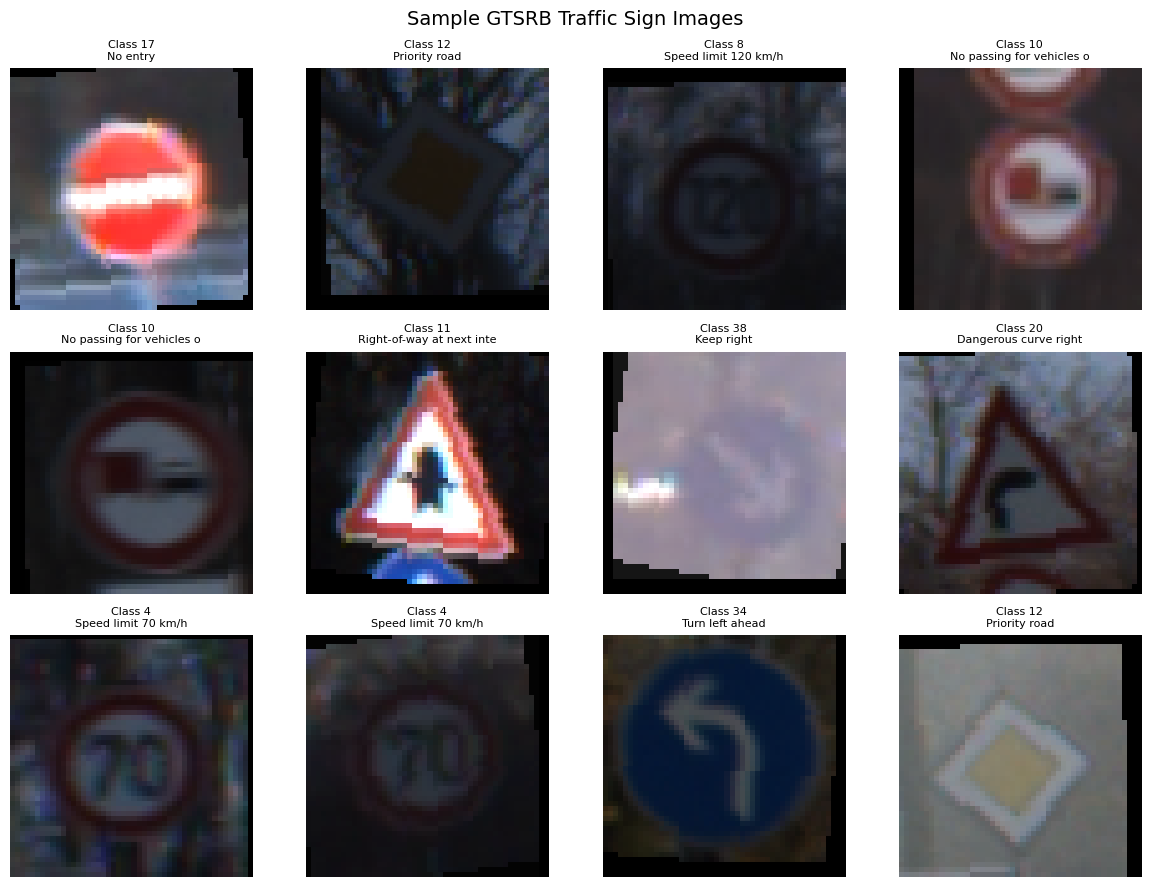

In [16]:
def denormalize(image):
    """
    Convert normalized image tensor back to displayable range.
    """
    image = image * 0.5 + 0.5
    return image.clamp(0, 1)


images, labels = next(iter(train_loader))

plt.figure(figsize=(12, 9))

for i in range(12):

    image = denormalize(images[i])

    # Convert PyTorch CHW format to Matplotlib HWC format
    image = image.permute(1, 2, 0)

    class_id = labels[i].item()

    plt.subplot(3, 4, i + 1)

    plt.imshow(image)

    plt.title(
        f"Class {class_id}\n"
        f"{class_names[class_id][:25]}",
        fontsize=8
    )

    plt.axis("off")

plt.suptitle(
    "Sample GTSRB Traffic Sign Images",
    fontsize=14
)

plt.tight_layout()
plt.show()

In [17]:
# Count samples belonging to each class
class_counts = np.bincount(
    targets,
    minlength=NUM_CLASSES
)

print("Number of classes:", len(class_counts))

print("\nClass distribution:")

for class_id, count in enumerate(class_counts):
    print(
        f"Class {class_id:2d}: "
        f"{count:5d} images - "
        f"{class_names[class_id]}"
    )

Number of classes: 43

Class distribution:
Class  0:   150 images - Speed limit 20 km/h
Class  1:  1500 images - Speed limit 30 km/h
Class  2:  1500 images - Speed limit 50 km/h
Class  3:   960 images - Speed limit 60 km/h
Class  4:  1320 images - Speed limit 70 km/h
Class  5:  1260 images - Speed limit 80 km/h
Class  6:   300 images - End of speed limit 80 km/h
Class  7:   960 images - Speed limit 100 km/h
Class  8:   960 images - Speed limit 120 km/h
Class  9:   990 images - No passing
Class 10:  1350 images - No passing for vehicles over 3.5 tons
Class 11:   900 images - Right-of-way at next intersection
Class 12:  1410 images - Priority road
Class 13:  1440 images - Yield
Class 14:   540 images - Stop
Class 15:   420 images - No vehicles
Class 16:   300 images - Vehicles over 3.5 tons prohibited
Class 17:   750 images - No entry
Class 18:   810 images - General caution
Class 19:   150 images - Dangerous curve left
Class 20:   240 images - Dangerous curve right
Class 21:   240 image

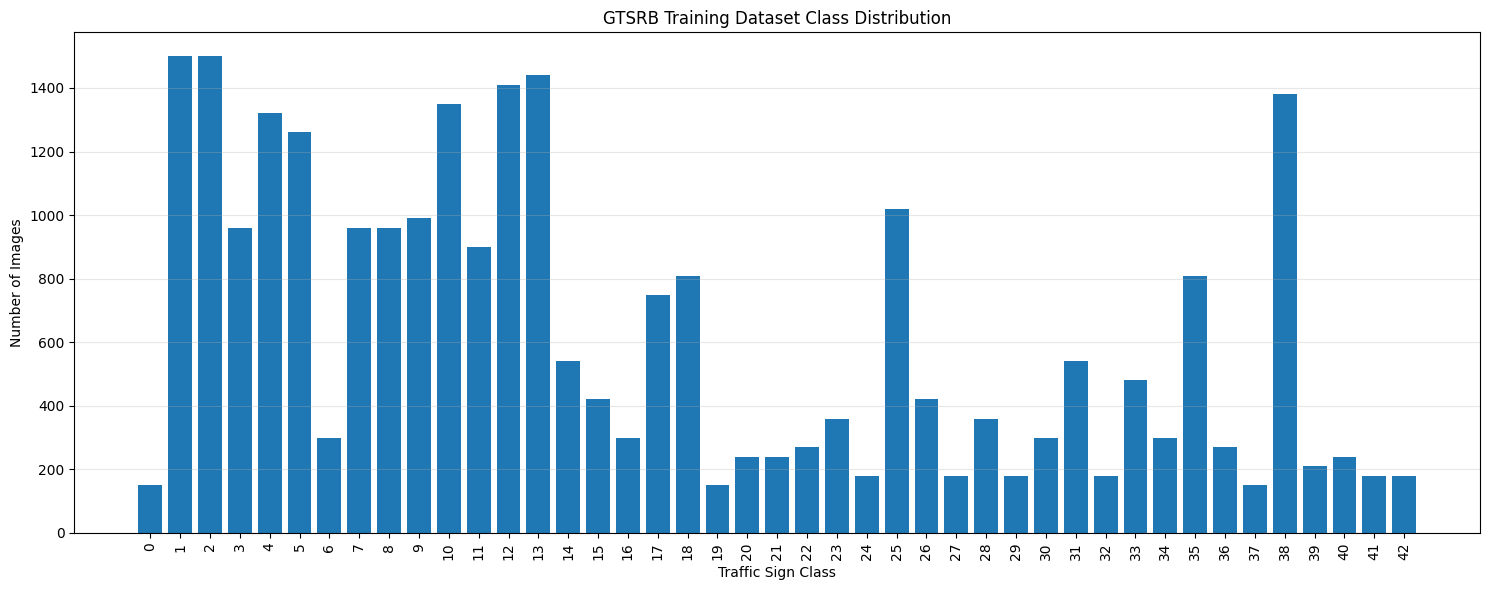

In [18]:
plt.figure(figsize=(15, 6))

plt.bar(
    range(NUM_CLASSES),
    class_counts
)

plt.xlabel("Traffic Sign Class")
plt.ylabel("Number of Images")

plt.title(
    "GTSRB Training Dataset Class Distribution"
)

plt.xticks(
    range(NUM_CLASSES),
    rotation=90
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

In [20]:
class TrafficSignCNN(nn.Module):

    def __init__(
        self,
        num_classes=43,
        dropout=0.4
    ):

        super().__init__()

        # =========================
        # FEATURE EXTRACTION
        # =========================

        self.features = nn.Sequential(

            # ---- Block 1 ----
            nn.Conv2d(
                in_channels=3,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(32),

            nn.ReLU(inplace=True),

            nn.MaxPool2d(
                kernel_size=2
            ),


            # ---- Block 2 ----
            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(64),

            nn.ReLU(inplace=True),

            nn.MaxPool2d(
                kernel_size=2
            ),


            # ---- Block 3 ----
            nn.Conv2d(
                in_channels=64,
                out_channels=128,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(128),

            nn.ReLU(inplace=True),

            nn.MaxPool2d(
                kernel_size=2
            ),


            # ---- Block 4 ----
            nn.Conv2d(
                in_channels=128,
                out_channels=256,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(256),

            nn.ReLU(inplace=True),

            # Convert feature maps to 1x1
            nn.AdaptiveAvgPool2d(
                (1, 1)
            )
        )


        # =========================
        # CLASSIFICATION HEAD
        # =========================

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Dropout(
                p=dropout
            ),

            nn.Linear(
                in_features=256,
                out_features=num_classes
            )
        )


    def forward(self, x):

        x = self.features(x)

        x = self.classifier(x)

        return x

In [21]:
model = TrafficSignCNN(
    num_classes=NUM_CLASSES,
    dropout=DROPOUT
)

model = model.to(device)

print(model)

TrafficSignCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.

In [22]:
total_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
)

trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

print(
    f"Total parameters: {total_parameters:,}"
)

print(
    f"Trainable parameters: {trainable_parameters:,}"
)

Total parameters: 400,427
Trainable parameters: 400,427


In [23]:
# Multi-class classification loss
criterion = nn.CrossEntropyLoss()


# Adam optimizer with L2 regularization
optimizer = optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)


# Reduce learning rate when validation loss stops improving
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2
)


print("Loss Function:")
print(criterion)

print("\nOptimizer:")
print(optimizer)

print("\nLearning Rate:", LEARNING_RATE)
print("Weight Decay:", WEIGHT_DECAY)
print("Dropout:", DROPOUT)

Loss Function:
CrossEntropyLoss()

Optimizer:
Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0.0001
)

Learning Rate: 0.001
Weight Decay: 0.0001
Dropout: 0.4


In [24]:
def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    device
):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    progress_bar = tqdm(
        loader,
        desc="Training",
        leave=False
    )


    for images, labels in progress_bar:

        # Move data to GPU/CPU
        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )


        # Reset gradients
        optimizer.zero_grad()


        # Forward pass
        outputs = model(images)


        # Calculate loss
        loss = criterion(
            outputs,
            labels
        )


        # Backpropagation
        loss.backward()


        # Update model parameters
        optimizer.step()


        # Calculate total loss
        running_loss += (
            loss.item()
            * images.size(0)
        )


        # Get predicted classes
        predictions = outputs.argmax(
            dim=1
        )


        # Count correct predictions
        correct += (
            predictions == labels
        ).sum().item()

        total += labels.size(0)


        # Show current batch loss
        progress_bar.set_postfix(
            loss=f"{loss.item():.4f}"
        )


    epoch_loss = (
        running_loss / total
    )

    epoch_accuracy = (
        correct / total
    )


    return (
        epoch_loss,
        epoch_accuracy
    )

In [25]:
@torch.no_grad()
def evaluate(
    model,
    loader,
    criterion,
    device
):

    model.eval()

    running_loss = 0.0

    correct = 0
    total = 0

    all_labels = []
    all_predictions = []
    all_probabilities = []


    for images, labels in loader:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )


        # Forward pass
        outputs = model(images)


        # Calculate loss
        loss = criterion(
            outputs,
            labels
        )


        # Convert outputs to probabilities
        probabilities = torch.softmax(
            outputs,
            dim=1
        )


        # Predicted class
        predictions = outputs.argmax(
            dim=1
        )


        running_loss += (
            loss.item()
            * images.size(0)
        )


        correct += (
            predictions == labels
        ).sum().item()

        total += labels.size(0)


        # Store labels
        all_labels.extend(
            labels.cpu().numpy()
        )


        # Store predictions
        all_predictions.extend(
            predictions.cpu().numpy()
        )


        # Store probabilities
        all_probabilities.append(
            probabilities.cpu()
        )


    epoch_loss = (
        running_loss / total
    )

    epoch_accuracy = (
        correct / total
    )


    all_probabilities = torch.cat(
        all_probabilities,
        dim=0
    ).numpy()


    return (
        epoch_loss,
        epoch_accuracy,
        np.array(all_labels),
        np.array(all_predictions),
        all_probabilities
    )

In [26]:
history = {
    "train_loss": [],
    "val_loss": [],
    "train_accuracy": [],
    "val_accuracy": []
}


best_val_loss = float("inf")

patience = 4
patience_counter = 0

MODEL_PATH = (
    "traffic_sign_cnn_best.pth"
)


for epoch in range(NUM_EPOCHS):

    print(
        "\n" + "=" * 65
    )

    print(
        f"Epoch {epoch + 1}/{NUM_EPOCHS}"
    )

    print(
        "=" * 65
    )


    # -------------------------
    # Training
    # -------------------------

    train_loss, train_accuracy = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )


    # -------------------------
    # Validation
    # -------------------------

    (
        val_loss,
        val_accuracy,
        _,
        _,
        _
    ) = evaluate(
        model,
        val_loader,
        criterion,
        device
    )


    # Update learning rate
    scheduler.step(
        val_loss
    )


    # Store results
    history["train_loss"].append(
        train_loss
    )

    history["val_loss"].append(
        val_loss
    )

    history["train_accuracy"].append(
        train_accuracy
    )

    history["val_accuracy"].append(
        val_accuracy
    )


    # Print results
    print(
        f"Train Loss     : {train_loss:.4f}"
    )

    print(
        f"Train Accuracy : "
        f"{train_accuracy * 100:.2f}%"
    )

    print(
        f"Validation Loss: {val_loss:.4f}"
    )

    print(
        f"Validation Acc : "
        f"{val_accuracy * 100:.2f}%"
    )

    print(
        f"Learning Rate  : "
        f"{optimizer.param_groups[0]['lr']:.6f}"
    )


    # -------------------------
    # Save best model
    # -------------------------

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        patience_counter = 0

        torch.save(
            model.state_dict(),
            MODEL_PATH
        )

        print(
            "✓ Best model saved"
        )

    else:

        patience_counter += 1

        print(
            f"No improvement: "
            f"{patience_counter}/{patience}"
        )


    # -------------------------
    # Early stopping
    # -------------------------

    if patience_counter >= patience:

        print(
            "\nEarly stopping triggered."
        )

        break


Epoch 1/15


Training:   0%|          | 0/167 [00:00<?, ?it/s]

Train Loss     : 2.5293
Train Accuracy : 29.67%
Validation Loss: 1.7600
Validation Acc : 44.26%
Learning Rate  : 0.001000
✓ Best model saved

Epoch 2/15


Training:   0%|          | 0/167 [00:00<?, ?it/s]

Train Loss     : 1.3478
Train Accuracy : 61.12%
Validation Loss: 0.9883
Validation Acc : 69.41%
Learning Rate  : 0.001000
✓ Best model saved

Epoch 3/15


...

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7fa554920040>
Traceback (most recent call last):
Exception ignored in:   File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
<function _MultiProcessingDataLoaderIter.__del__ at 0x7fa554920040>  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers

Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
    if w.is_alive():  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers

      File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
if w.is_alive():    
assert self._parent_pid == os.getpid(), 'can only test a child process'  File "/usr/lib/python3.13/multiprocessing/process.py", line 16

Train Loss     : 0.0668
Train Accuracy : 98.28%
Validation Loss: 0.1131
Validation Acc : 96.42%
Learning Rate  : 0.001000
No improvement: 1/4

Epoch 15/15


Training:   0%|          | 0/167 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7fa554920040>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
Exception ignored in:     <function _MultiProcessingDataLoaderIter.__del__ at 0x7fa554920040>self._shutdown_workers()
Traceback (most recent call last):

  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
        self._shutdown_workers()
if w.is_alive():
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
        if w.is_alive():assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError
  File "/usr/lib/python3.13/multiprocessing/proce

Train Loss     : 0.0633
Train Accuracy : 98.43%
Validation Loss: 0.1838
Validation Acc : 95.10%
Learning Rate  : 0.001000
No improvement: 2/4


In [27]:
model.load_state_dict(
    torch.load(
        MODEL_PATH,
        map_location=device
    )
)

model = model.to(device)

print(
    "Best validation model loaded successfully."
)

Best validation model loaded successfully.


In [28]:
history_df = pd.DataFrame({

    "Epoch": np.arange(
        1,
        len(history["train_loss"]) + 1
    ),

    "Training Loss":
        history["train_loss"],

    "Validation Loss":
        history["val_loss"],

    "Training Accuracy":
        np.array(
            history["train_accuracy"]
        ) * 100,

    "Validation Accuracy":
        np.array(
            history["val_accuracy"]
        ) * 100
})


display(
    history_df.round(4)
)

,Epoch,Training Loss,Validation Loss,Training Accuracy,Validation Accuracy
0,1,2.5293,1.7600,29.6734,44.2568
1,2,1.3478,0.9883,61.1158,69.4069
2,3,0.7481,0.6671,79.5749,79.0916
3,4,0.4691,1.0036,87.8519,71.3964
4,5,0.3174,0.4320,92.1077,86.8243
5,6,0.2517,0.3344,93.6702,90.2027
6,7,0.1871,0.3564,95.0779,89.3393
7,8,0.1493,0.2167,96.2885,93.7312
8,9,0.1339,0.1559,96.5841,95.4204
9,10,0.1156,0.2230,97.1190,92.7365


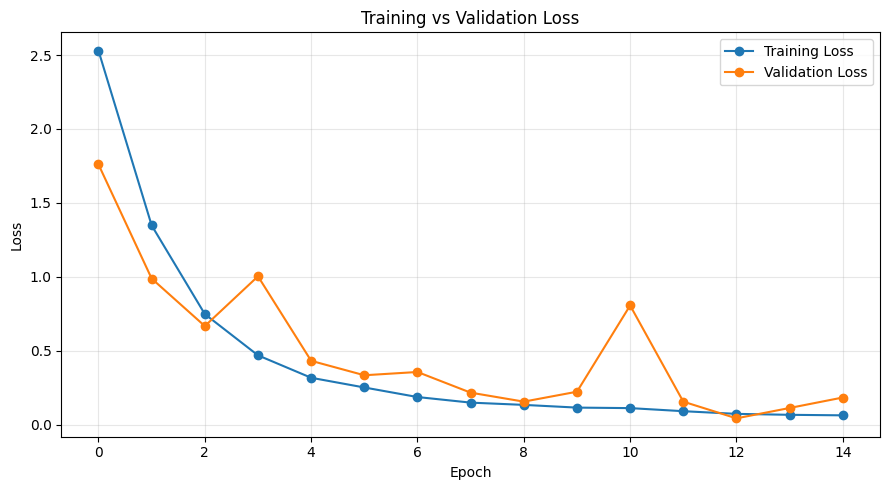

In [29]:
plt.figure(
    figsize=(9, 5)
)

plt.plot(
    history["train_loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    history["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "Training vs Validation Loss"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()

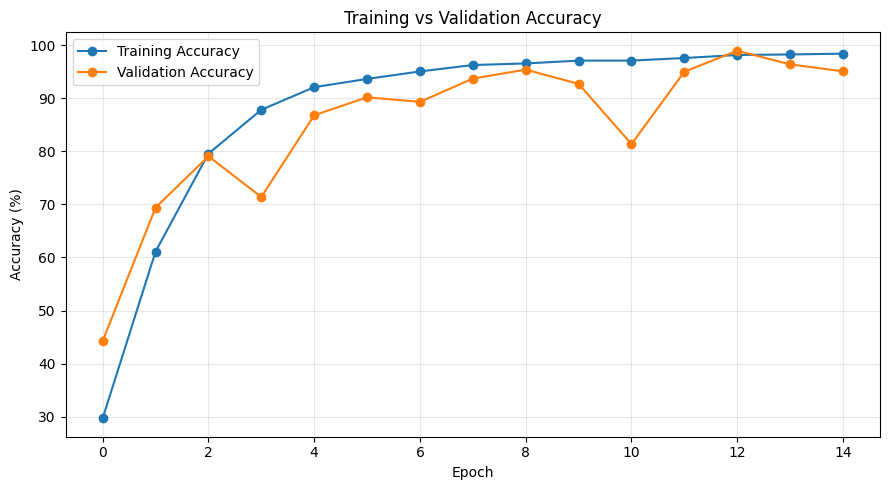

In [30]:
plt.figure(
    figsize=(9, 5)
)

plt.plot(
    np.array(
        history["train_accuracy"]
    ) * 100,
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    np.array(
        history["val_accuracy"]
    ) * 100,
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")

plt.ylabel(
    "Accuracy (%)"
)

plt.title(
    "Training vs Validation Accuracy"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()

In [31]:
(
    test_loss,
    test_accuracy,
    y_true,
    y_pred,
    y_prob
) = evaluate(
    model,
    test_loader,
    criterion,
    device
)


print(
    "=" * 50
)

print(
    "FINAL TEST RESULTS"
)

print(
    "=" * 50
)

print(
    f"Test Loss     : {test_loss:.4f}"
)

print(
    f"Test Accuracy : "
    f"{test_accuracy * 100:.2f}%"
)

FINAL TEST RESULTS
Test Loss     : 0.2599
Test Accuracy : 92.85%


In [32]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=4,
        zero_division=0
    )
)

                                             precision    recall  f1-score   support

                        Speed limit 20 km/h     1.0000    0.8833    0.9381        60
                        Speed limit 30 km/h     0.9021    0.9722    0.9358       720
                        Speed limit 50 km/h     0.9985    0.8653    0.9271       750
                        Speed limit 60 km/h     0.9195    0.9133    0.9164       450
                        Speed limit 70 km/h     0.9872    0.9348    0.9603       660
                        Speed limit 80 km/h     0.7971    0.9667    0.8737       630
                 End of speed limit 80 km/h     0.9545    0.8400    0.8936       150
                       Speed limit 100 km/h     0.9252    0.9622    0.9434       450
                       Speed limit 120 km/h     0.9769    0.8444    0.9058       450
                                 No passing     0.9418    0.9437    0.9428       480
      No passing for vehicles over 3.5 tons     0.9984    0.9530

Confusion Matrix Shape: (43, 43)


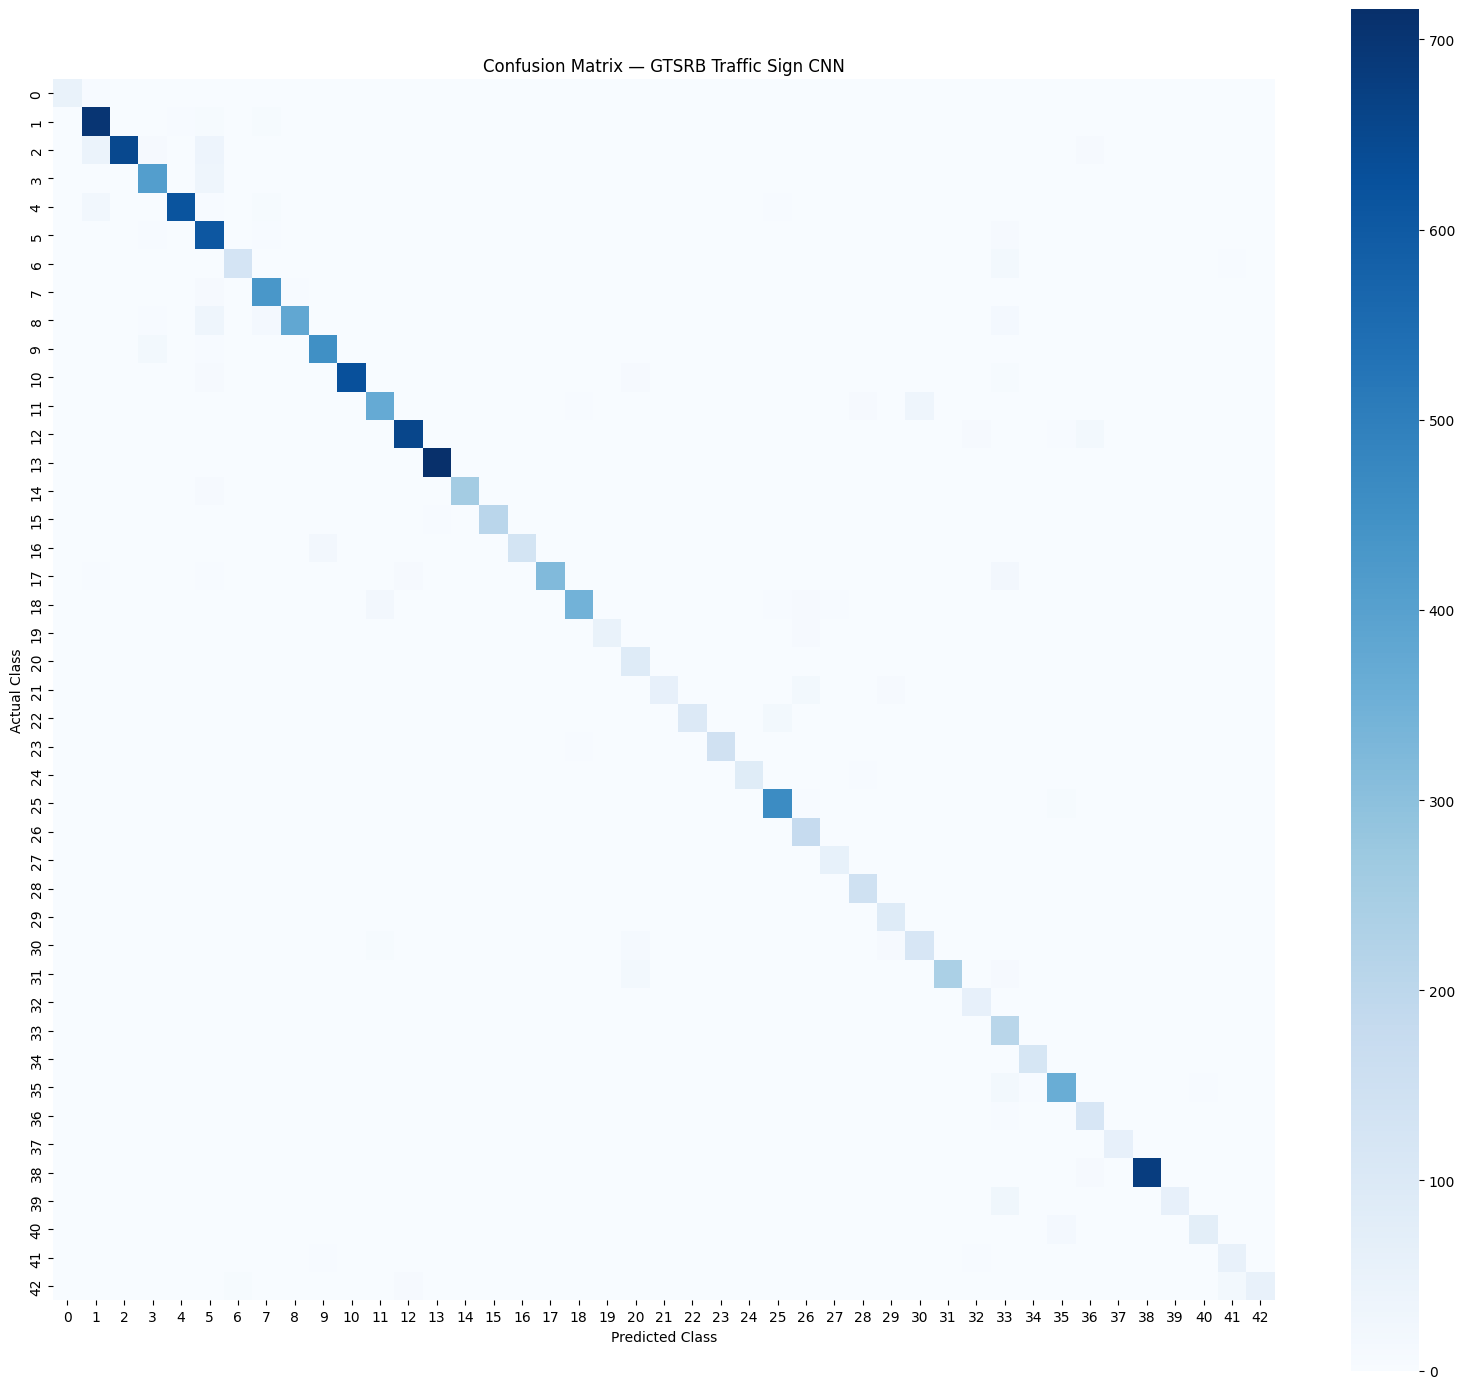

In [33]:
cm = confusion_matrix(
    y_true,
    y_pred
)

print(
    "Confusion Matrix Shape:",
    cm.shape
)


plt.figure(
    figsize=(16, 14)
)

sns.heatmap(
    cm,
    cmap="Blues",
    annot=False,
    square=True,
    xticklabels=range(NUM_CLASSES),
    yticklabels=range(NUM_CLASSES)
)

plt.xlabel(
    "Predicted Class"
)

plt.ylabel(
    "Actual Class"
)

plt.title(
    "Confusion Matrix — GTSRB Traffic Sign CNN"
)

plt.tight_layout()

plt.show()

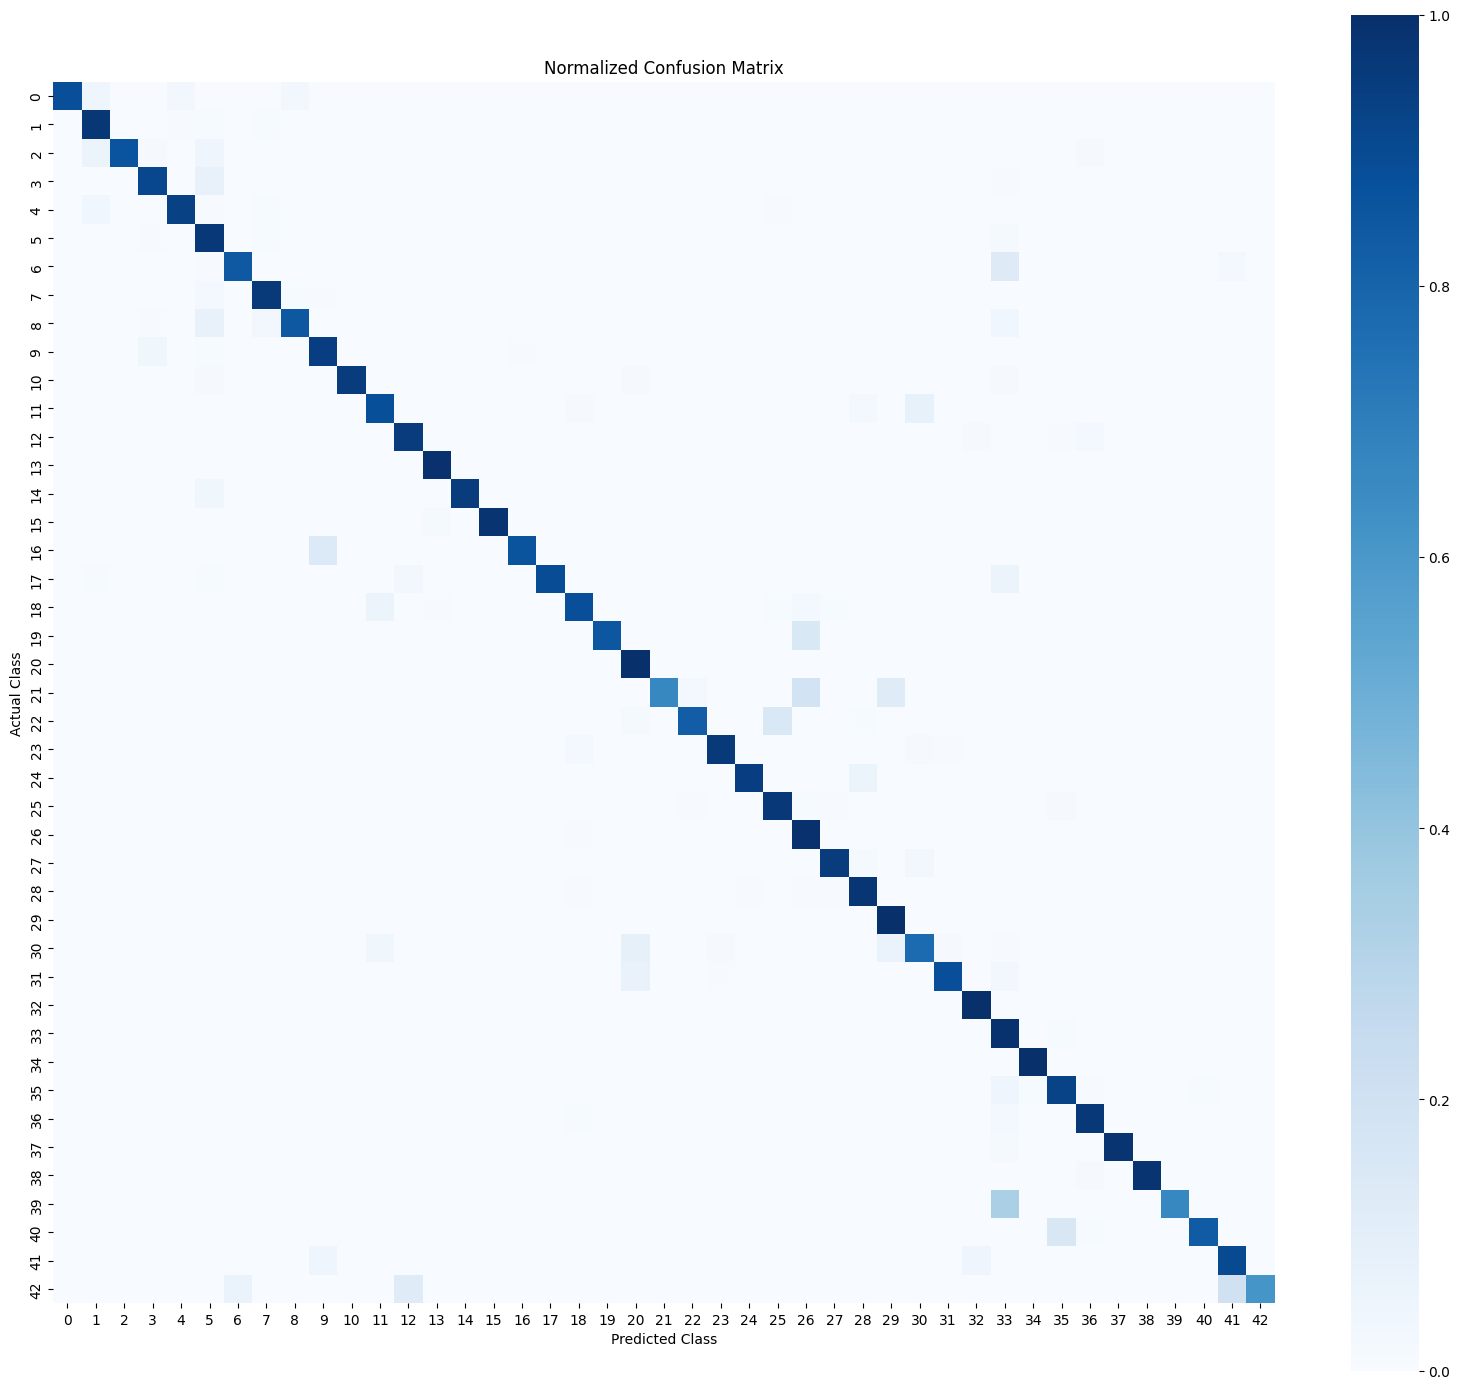

In [34]:
# Normalize each row
cm_normalized = (
    cm.astype(float)
    /
    np.maximum(
        cm.sum(axis=1, keepdims=True),
        1
    )
)


plt.figure(
    figsize=(16, 14)
)

sns.heatmap(
    cm_normalized,
    cmap="Blues",
    annot=False,
    square=True,
    vmin=0,
    vmax=1,
    xticklabels=range(NUM_CLASSES),
    yticklabels=range(NUM_CLASSES)
)

plt.xlabel(
    "Predicted Class"
)

plt.ylabel(
    "Actual Class"
)

plt.title(
    "Normalized Confusion Matrix"
)

plt.tight_layout()

plt.show()

In [35]:
class_accuracy = []

class_sample_count = []


for class_id in range(NUM_CLASSES):

    mask = (
        y_true == class_id
    )

    sample_count = mask.sum()

    class_sample_count.append(
        sample_count
    )


    if sample_count > 0:

        accuracy = (
            y_pred[mask] == class_id
        ).mean()

    else:

        accuracy = 0.0


    class_accuracy.append(
        accuracy
    )


class_accuracy_df = pd.DataFrame({

    "Class ID":
        range(NUM_CLASSES),

    "Class Name":
        class_names,

    "Samples":
        class_sample_count,

    "Accuracy (%)":
        np.array(
            class_accuracy
        ) * 100
})


display(
    class_accuracy_df.round(2)
)

,Class ID,Class Name,Samples,Accuracy (%)
0,0,Speed limit 20 km/h,60,88.33
1,1,Speed limit 30 km/h,720,97.22
2,2,Speed limit 50 km/h,750,86.53
3,3,Speed limit 60 km/h,450,91.33
4,4,Speed limit 70 km/h,660,93.48
5,5,Speed limit 80 km/h,630,96.67
6,6,End of speed limit 80 km/h,150,84.00
7,7,Speed limit 100 km/h,450,96.22
8,8,Speed limit 120 km/h,450,84.44
9,9,No passing,480,94.38


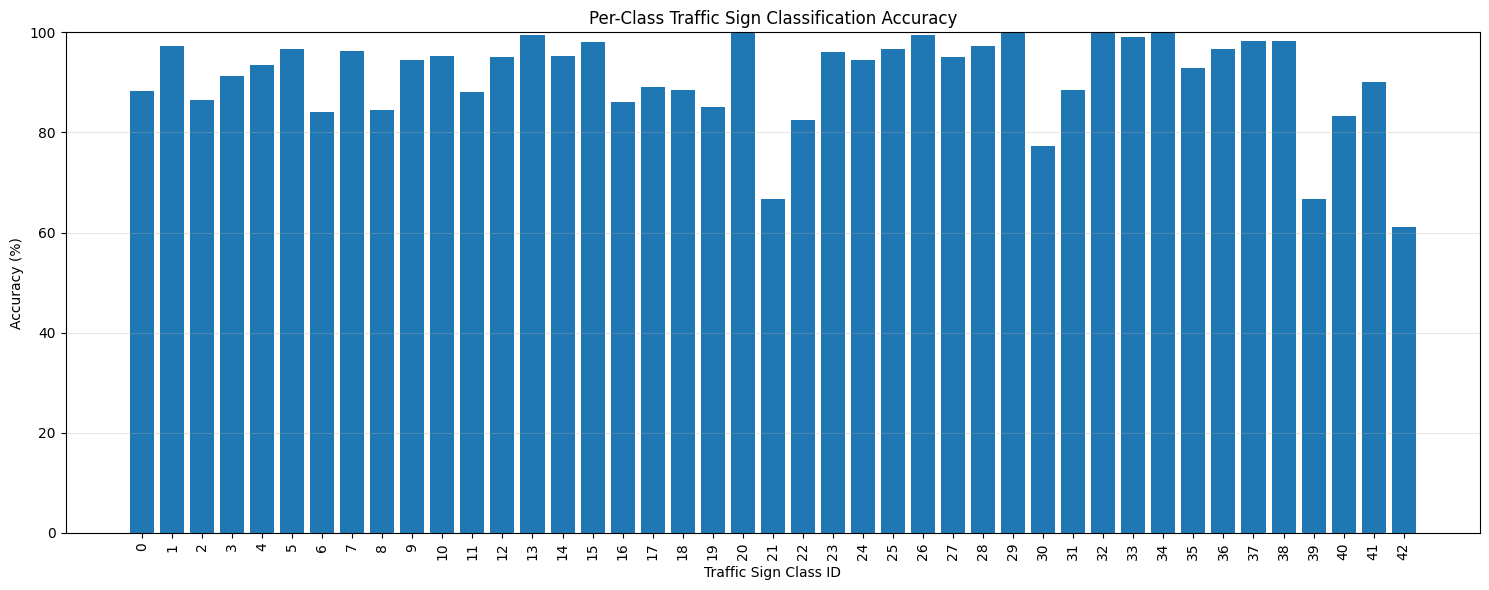

In [36]:
plt.figure(
    figsize=(15, 6)
)

plt.bar(
    class_accuracy_df["Class ID"],
    class_accuracy_df["Accuracy (%)"]
)

plt.xlabel(
    "Traffic Sign Class ID"
)

plt.ylabel(
    "Accuracy (%)"
)

plt.title(
    "Per-Class Traffic Sign Classification Accuracy"
)

plt.xticks(
    range(NUM_CLASSES),
    rotation=90
)

plt.ylim(
    0,
    100
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.show()

In [37]:
# Highest predicted probability for every test image
predicted_confidence = y_prob.max(
    axis=1
)


confidence_df = pd.DataFrame({

    "True Class":
        y_true,

    "Predicted Class":
        y_pred,

    "Confidence (%)":
        predicted_confidence * 100
})


confidence_df["Correct"] = (
    confidence_df["True Class"]
    ==
    confidence_df["Predicted Class"]
)


confidence_df["True Class Name"] = (
    confidence_df["True Class"].apply(
        lambda x: class_names[x]
    )
)


confidence_df["Predicted Class Name"] = (
    confidence_df["Predicted Class"].apply(
        lambda x: class_names[x]
    )
)


display(
    confidence_df.head(20).round(2)
)

,True Class,Predicted Class,Confidence (%),Correct,True Class Name,Predicted Class Name
0,16,16,99.930000,True,Vehicles over 3.5 tons prohibited,Vehicles over 3.5 tons prohibited
1,1,1,100.000000,True,Speed limit 30 km/h,Speed limit 30 km/h
2,38,38,100.000000,True,Keep right,Keep right
3,33,33,99.860001,True,Turn right ahead,Turn right ahead
4,11,11,99.620003,True,Right-of-way at next intersection,Right-of-way at next intersection
5,38,38,100.000000,True,Keep right,Keep right
6,18,18,100.000000,True,General caution,General caution
7,12,12,99.599998,True,Priority road,Priority road
8,25,25,100.000000,True,Road work,Road work
9,35,35,99.779999,True,Ahead only,Ahead only


In [38]:
class_confidence = (
    confidence_df
    .groupby(
        "True Class"
    )["Confidence (%)"]
    .mean()
    .reset_index()
)


class_confidence["Class Name"] = (
    class_confidence["True Class"].apply(
        lambda x: class_names[x]
    )
)


class_confidence = class_confidence[
    [
        "True Class",
        "Class Name",
        "Confidence (%)"
    ]
]


display(
    class_confidence.round(2)
)

,True Class,Class Name,Confidence (%)
0,0,Speed limit 20 km/h,84.309998
1,1,Speed limit 30 km/h,96.660004
2,2,Speed limit 50 km/h,90.000000
3,3,Speed limit 60 km/h,94.000000
4,4,Speed limit 70 km/h,95.519997
5,5,Speed limit 80 km/h,95.889999
6,6,End of speed limit 80 km/h,87.790001
7,7,Speed limit 100 km/h,92.970001
8,8,Speed limit 120 km/h,86.320000
9,9,No passing,96.480003


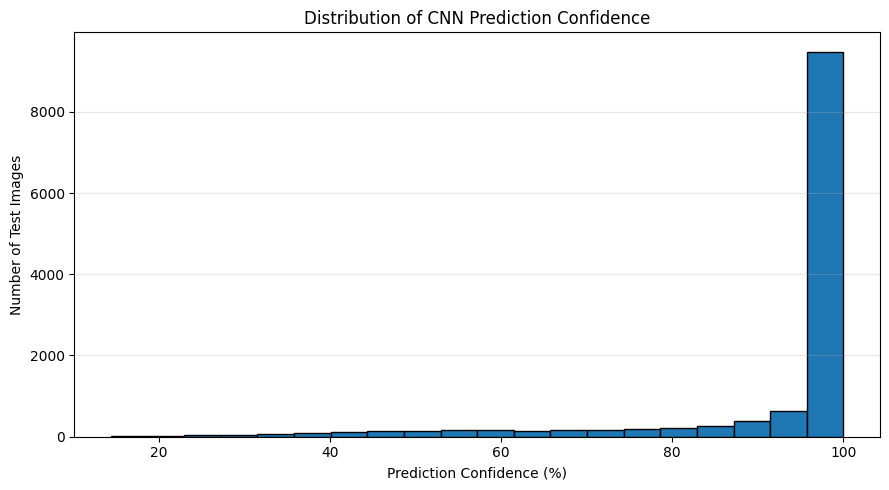

In [39]:
plt.figure(
    figsize=(9, 5)
)

plt.hist(
    predicted_confidence * 100,
    bins=20,
    edgecolor="black"
)

plt.xlabel(
    "Prediction Confidence (%)"
)

plt.ylabel(
    "Number of Test Images"
)

plt.title(
    "Distribution of CNN Prediction Confidence"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.show()

In [40]:
@torch.no_grad()
def collect_misclassified(
    model,
    loader,
    device,
    max_images=12
):

    model.eval()

    images_list = []
    true_list = []
    predicted_list = []
    confidence_list = []


    for images, labels in loader:

        images_device = images.to(
            device,
            non_blocking=True
        )


        outputs = model(
            images_device
        )


        probabilities = torch.softmax(
            outputs,
            dim=1
        )


        predictions = outputs.argmax(
            dim=1
        )


        confidence = probabilities.max(
            dim=1
        ).values


        wrong_indices = torch.where(
            predictions.cpu() != labels
        )[0]


        for index in wrong_indices:

            images_list.append(
                images[index].cpu()
            )

            true_list.append(
                labels[index].item()
            )

            predicted_list.append(
                predictions[index].item()
            )

            confidence_list.append(
                confidence[index].item()
            )


            if len(images_list) >= max_images:

                return (
                    images_list,
                    true_list,
                    predicted_list,
                    confidence_list
                )


    return (
        images_list,
        true_list,
        predicted_list,
        confidence_list
    )

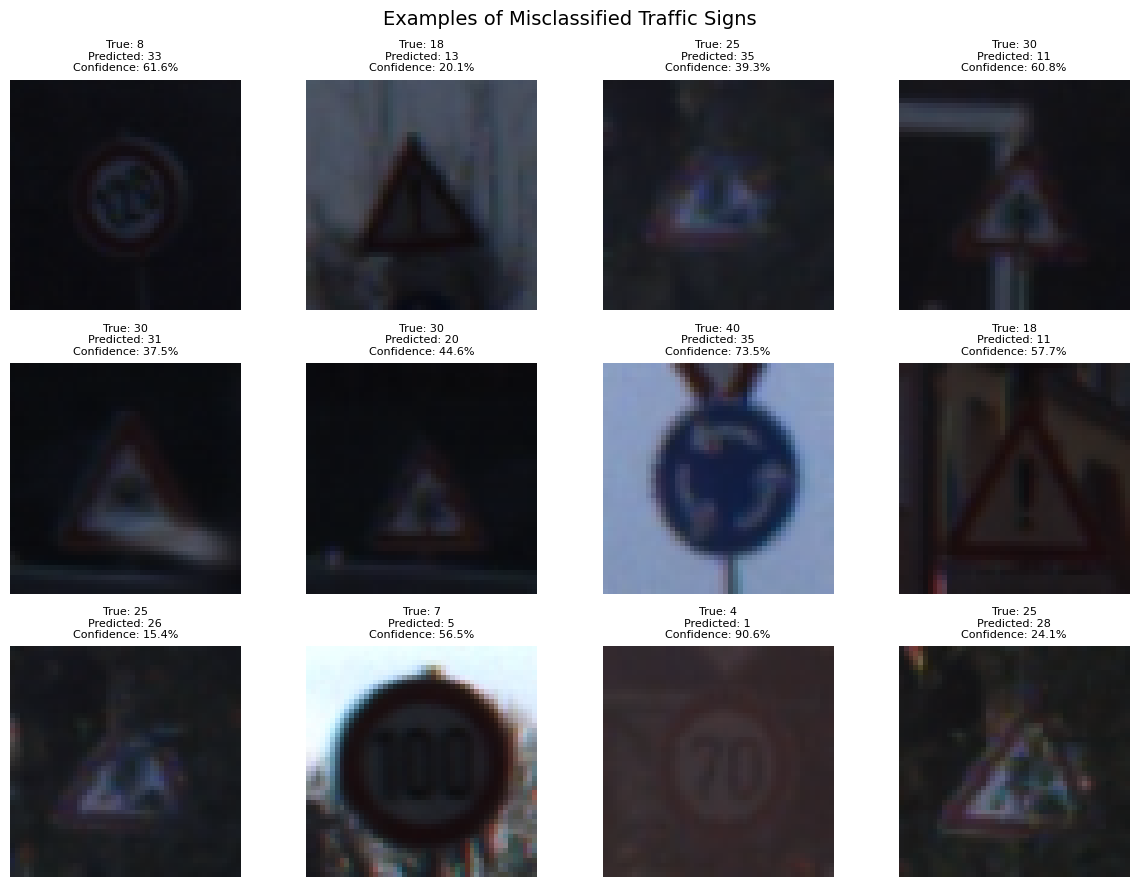

In [41]:
(
    wrong_images,
    wrong_true,
    wrong_pred,
    wrong_conf
) = collect_misclassified(
    model,
    test_loader,
    device,
    max_images=12
)


plt.figure(
    figsize=(12, 9)
)


for i in range(
    len(wrong_images)
):

    image = denormalize(
        wrong_images[i]
    )

    image = image.permute(
        1, 2, 0
    )


    plt.subplot(
        3,
        4,
        i + 1
    )


    plt.imshow(image)


    plt.title(
        f"True: {wrong_true[i]}\n"
        f"Predicted: {wrong_pred[i]}\n"
        f"Confidence: "
        f"{wrong_conf[i] * 100:.1f}%",
        fontsize=8
    )


    plt.axis("off")


plt.suptitle(
    "Examples of Misclassified Traffic Signs",
    fontsize=14
)

plt.tight_layout()

plt.show()

In [42]:
wrong_mask = (
    y_true != y_pred
)


wrong_analysis = pd.DataFrame({

    "True Class":
        y_true[wrong_mask],

    "Predicted Class":
        y_pred[wrong_mask],

    "Confidence (%)":
        predicted_confidence[wrong_mask] * 100
})


wrong_analysis["True Class Name"] = (
    wrong_analysis["True Class"].apply(
        lambda x: class_names[x]
    )
)


wrong_analysis["Predicted Class Name"] = (
    wrong_analysis["Predicted Class"].apply(
        lambda x: class_names[x]
    )
)


wrong_analysis = wrong_analysis.sort_values(
    "Confidence (%)",
    ascending=False
)


display(
    wrong_analysis.head(15).round(2)
)

,True Class,Predicted Class,Confidence (%),True Class Name,Predicted Class Name
490,39,33,99.889999,Keep left,Turn right ahead
266,8,5,99.769997,Speed limit 120 km/h,Speed limit 80 km/h
450,8,5,99.690002,Speed limit 120 km/h,Speed limit 80 km/h
637,39,33,99.480003,Keep left,Turn right ahead
699,3,5,99.269997,Speed limit 60 km/h,Speed limit 80 km/h
369,9,3,99.239998,No passing,Speed limit 60 km/h
81,8,5,99.169998,Speed limit 120 km/h,Speed limit 80 km/h
765,39,33,99.129997,Keep left,Turn right ahead
270,3,5,99.070000,Speed limit 60 km/h,Speed limit 80 km/h
54,2,1,99.040001,Speed limit 50 km/h,Speed limit 30 km/h


In [43]:
FINAL_MODEL_PATH = (
    "Assignment_06_Traffic_Sign_CNN.pth"
)


torch.save(
    {
        "model_state_dict":
            model.state_dict(),

        "class_names":
            class_names,

        "num_classes":
            NUM_CLASSES,

        "image_size":
            IMG_SIZE,

        "dropout":
            DROPOUT,

        "test_accuracy":
            test_accuracy
    },
    FINAL_MODEL_PATH
)


print(
    "Model saved successfully:"
)

print(
    FINAL_MODEL_PATH
)

Model saved successfully:
Assignment_06_Traffic_Sign_CNN.pth


In [44]:
final_results = pd.DataFrame({

    "Metric": [
        "Test Loss",
        "Test Accuracy",
        "Number of Classes",
        "Image Size",
        "Batch Size",
        "Dropout",
        "Learning Rate",
        "Weight Decay",
        "Epochs Completed"
    ],

    "Value": [

        round(
            test_loss,
            4
        ),

        f"{test_accuracy * 100:.2f}%",

        NUM_CLASSES,

        f"{IMG_SIZE} × {IMG_SIZE}",

        BATCH_SIZE,

        DROPOUT,

        LEARNING_RATE,

        WEIGHT_DECAY,

        len(
            history["train_loss"]
        )
    ]
})


display(
    final_results
)

,Metric,Value
0,Test Loss,0.2599
1,Test Accuracy,92.85%
2,Number of Classes,43
3,Image Size,48 × 48
4,Batch Size,128
5,Dropout,0.4
6,Learning Rate,0.001
7,Weight Decay,0.0001
8,Epochs Completed,15


# Observations

1. The GTSRB dataset was successfully loaded and divided into training,
   validation and testing subsets.

2. Training images were resized and normalized. Data augmentation was
   applied to the training images to improve model generalization.

3. A Convolutional Neural Network was implemented using PyTorch with
   Conv2D, Batch Normalization, ReLU activation and Max Pooling layers.

4. Dropout with a probability of 0.4 was included to reduce overfitting.

5. Cross-Entropy Loss was used for the multi-class classification problem.

6. The Adam optimizer with L2 weight decay was used for model optimization
   and regularization.

7. Training and validation loss and accuracy were monitored across epochs.

8. The final model was evaluated on the unseen GTSRB test dataset.

9. A confusion matrix was generated to analyze class-level prediction
   errors.

10. Per-class accuracy and prediction confidence were calculated to study
    the model's performance across individual traffic-sign categories.

11. Misclassified traffic-sign images were visualized to understand
    challenging classification cases.